In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from datetime import datetime as dt
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [28]:
# Leitura dos Parquets da Bronze
df_inc = pd.read_parquet('data/bronze/incidents_master/incidents_master.parquet')
df_fin = pd.read_parquet('data/bronze/financial_impact/financial_impact.parquet')
df_mkt = pd.read_parquet('data/bronze/market_impact/market_impact.parquet')

print('incidents_master :', df_inc.shape)
print('financial_impact :', df_fin.shape)
print('market_impact    :', df_mkt.shape)

incidents_master : (850, 36)
financial_impact : (778, 23)
market_impact    : (358, 35)


In [29]:
# Descarte das colunas de metadados da Bronze
meta_cols = ['_ingestion_timestamp', '_source_file', '_file_hash_sha256', '_file_size_bytes']

df_inc = df_inc.drop(columns=[c for c in meta_cols if c in df_inc.columns])
df_fin = df_fin.drop(columns=[c for c in meta_cols if c in df_fin.columns])
df_mkt = df_mkt.drop(columns=[c for c in meta_cols if c in df_mkt.columns])

df_inc.head(3)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,None,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,None,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,None,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


<details><summary>Dica</summary>

As três estratégias principais são:

- **Remover** a linha — quando o nulo torna o registro inutilizável para a análise
- **Imputar** um valor — moda para categóricas, mediana para numéricas
- **Rotular** o nulo — `'nao_informado'` quando o nulo tem significado de negócio

Pense: o nulo em `attribution_confidence` (43% dos registros) significa que o grupo não foi identificado — faz sentido remover ou rotular?

O nulo em `downtime_hours` (51%) pode significar que o dado não foi divulgado — não é a mesma coisa que zero horas.

</details>

In [30]:
df_silver_inc = df_inc.copy()
df_silver_fin = df_fin.copy()
df_silver_mkt = df_mkt.copy()

# Resumo de nulos antes do tratamento — incidents_master
nulos_antes = df_silver_inc.isnull().sum()
display(nulos_antes[nulos_antes > 0].sort_values(ascending=False))

review_flag                 780
industry_secondary          697
attack_vector_secondary     639
notes                       636
data_source_secondary       464
stock_ticker                438
downtime_hours              430
attribution_confidence      368
attributed_group            368
attack_chain                275
data_type                   248
data_compromised_records    248
dtype: int64

In [31]:
# ── incidents_master — tratamento de nulos

# Colunas categóricas para rotular nulo com 'nao_informado'
cols_rotular = [
    'industry_secondary', 'attack_vector_secondary',
    'attributed_group', 'attribution_confidence',
    'data_type', 'attack_chain', 'data_source_secondary', 'review_flag', 'notes'
]
for col in cols_rotular:
    if col in df_silver_inc.columns:
        df_silver_inc[col] = df_silver_inc[col].fillna('nao_informado')

df_silver_inc['stock_ticker'] = df_silver_inc['stock_ticker'].fillna('nao_listada')

mediana_records = df_silver_inc['data_compromised_records'].median()
df_silver_inc['data_compromised_records'] = df_silver_inc['data_compromised_records'].fillna(mediana_records)

mediana_downtime = df_silver_inc['downtime_hours'].median()
df_silver_inc['downtime_hours'] = df_silver_inc['downtime_hours'].fillna(mediana_downtime)

print('Nulos restantes — incidents_master:')
display(df_silver_inc.isnull().sum()[df_silver_inc.isnull().sum() > 0])

Nulos restantes — incidents_master:


Series([], dtype: int64)

In [32]:
# ── financial_impact — tratamento de nulos ────────────────────────────────


# nulo = incidente não foi ransomware; preencher com 0
df_silver_fin['ransom_demanded_usd'] = df_silver_fin['ransom_demanded_usd'].fillna(0)
df_silver_fin['ransom_paid_usd']     = df_silver_fin['ransom_paid_usd'].fillna(0)
df_silver_fin['ransom_source']       = df_silver_fin['ransom_source'].fillna('nao_aplicavel')

df_silver_fin['regulatory_fine_usd'] = df_silver_fin['regulatory_fine_usd'].fillna(0)

df_silver_fin['insurance_payout_usd'] = df_silver_fin['insurance_payout_usd'].fillna(0)

df_silver_fin['notes'] = df_silver_fin['notes'].fillna('nao_informado')

print('Nulos restantes — financial_impact:')
display(df_silver_fin.isnull().sum()[df_silver_fin.isnull().sum() > 0])

Nulos restantes — financial_impact:


Series([], dtype: int64)

In [33]:
# ── market_impact — tratamento de nulos

df_silver_mkt['days_to_price_recovery'] = df_silver_mkt['days_to_price_recovery'].fillna(-1)

df_silver_mkt['notes'] = df_silver_mkt['notes'].fillna('nao_informado')

print('Nulos restantes — market_impact:')
display(df_silver_mkt.isnull().sum()[df_silver_mkt.isnull().sum() > 0])

Nulos restantes — market_impact:


Series([], dtype: int64)

In [34]:
# Conversão de colunas de data — incidents_master
date_cols_inc = ['incident_date', 'discovery_date', 'disclosure_date', 'created_at', 'updated_at']
for col in date_cols_inc:
    df_silver_inc[col] = pd.to_datetime(df_silver_inc[col], errors='coerce', utc=True)

# Conversão de colunas de data — financial_impact
date_cols_fin = ['created_at', 'updated_at']
for col in date_cols_fin:
    df_silver_fin[col] = pd.to_datetime(df_silver_fin[col], errors='coerce', utc=True)

# Conversão de colunas de data — market_impact
date_cols_mkt = ['created_at', 'updated_at']
for col in date_cols_mkt:
    df_silver_mkt[col] = pd.to_datetime(df_silver_mkt[col], errors='coerce', utc=True)

print('Dtypes das datas — incidents_master:')
for col in date_cols_inc:
    print(f'  {col}: {df_silver_inc[col].dtype}')

Dtypes das datas — incidents_master:
  incident_date: datetime64[ns, UTC]
  discovery_date: datetime64[ns, UTC]
  disclosure_date: datetime64[ns, UTC]
  created_at: datetime64[ns, UTC]
  updated_at: datetime64[ns, UTC]


In [35]:
# Verificação dos tipos após conversão
df_silver_inc.dtypes

incident_id                              object
company_name                             object
company_revenue_usd                     float64
country_hq                               object
industry_primary                         object
industry_secondary                       object
employee_count                            int64
is_public_company                          bool
stock_ticker                             object
incident_date               datetime64[ns, UTC]
incident_date_estimated                    bool
discovery_date              datetime64[ns, UTC]
disclosure_date             datetime64[ns, UTC]
attack_vector_primary                    object
attack_vector_secondary                  object
attack_chain                             object
attributed_group                         object
attribution_confidence                   object
data_compromised_records                float64
data_type                                object
systems_affected                        

In [36]:
# Padronização de colunas categóricas — incidents_master
cat_cols_inc = [
    'attack_vector_primary', 'attack_vector_secondary',
    'attribution_confidence', 'data_type', 'data_source_type',
    'quality_grade', 'country_hq', 'industry_primary',
    'industry_secondary', 'attributed_group'
]
for col in cat_cols_inc:
    if col in df_silver_inc.columns:
        df_silver_inc[col] = df_silver_inc[col].str.lower().str.strip()

# Padronização de colunas categóricas — financial_impact
cat_cols_fin = ['direct_loss_method', 'total_loss_method', 'ransom_source']
for col in cat_cols_fin:
    df_silver_fin[col] = df_silver_fin[col].str.lower().str.strip()

# Padronização de colunas categóricas — market_impact
df_silver_mkt['sector_index'] = df_silver_mkt['sector_index'].str.lower().str.strip()

print('Valores únicos — attack_vector_primary:')
print(df_silver_inc['attack_vector_primary'].value_counts())

Valores únicos — attack_vector_primary:
attack_vector_primary
ransomware      228
phishing        147
data_breach     123
apt              84
malware          79
ddos             67
supply_chain     58
trojan           34
backdoor         30
Name: count, dtype: int64


In [37]:
# Verificação da padronização de attribution_confidence
print('attribution_confidence:')
print(df_silver_inc['attribution_confidence'].value_counts())

print('\nquality_grade:')
print(df_silver_inc['quality_grade'].value_counts())

attribution_confidence:
attribution_confidence
nao_informado    368
probable         172
suspected        168
unknown           79
confirmed         63
Name: count, dtype: int64

quality_grade:
quality_grade
silver    382
gold      311
bronze    157
Name: count, dtype: int64


In [38]:
# Remoção de duplicatas — incidents_master
shape_antes = df_silver_inc.shape
df_silver_inc = df_silver_inc.drop_duplicates()
df_silver_inc = df_silver_inc.drop_duplicates(subset=['incident_id'], keep='first')
df_silver_inc = df_silver_inc.reset_index(drop=True)
print(f'incidents_master: {shape_antes[0]} → {df_silver_inc.shape[0]} linhas (removidas: {shape_antes[0] - df_silver_inc.shape[0]})')

# Remoção de duplicatas — financial_impact
shape_antes = df_silver_fin.shape
df_silver_fin = df_silver_fin.drop_duplicates()
df_silver_fin = df_silver_fin.drop_duplicates(subset=['incident_id'], keep='first')
df_silver_fin = df_silver_fin.reset_index(drop=True)
print(f'financial_impact: {shape_antes[0]} → {df_silver_fin.shape[0]} linhas (removidas: {shape_antes[0] - df_silver_fin.shape[0]})')

# Remoção de duplicatas — market_impact
shape_antes = df_silver_mkt.shape
df_silver_mkt = df_silver_mkt.drop_duplicates()
df_silver_mkt = df_silver_mkt.drop_duplicates(subset=['incident_id'], keep='first')
df_silver_mkt = df_silver_mkt.reset_index(drop=True)
print(f'market_impact   : {shape_antes[0]} → {df_silver_mkt.shape[0]} linhas (removidas: {shape_antes[0] - df_silver_mkt.shape[0]})')

incidents_master: 850 → 850 linhas (removidas: 0)
financial_impact: 778 → 778 linhas (removidas: 0)
market_impact   : 358 → 358 linhas (removidas: 0)


In [39]:
# ── Colunas derivadas de data
df_silver_inc['ano_incidente']       = df_silver_inc['incident_date'].dt.year
df_silver_inc['mes_incidente']       = df_silver_inc['incident_date'].dt.month
df_silver_inc['trimestre_incidente'] = df_silver_inc['incident_date'].dt.quarter
df_silver_inc['dia_semana_incidente'] = df_silver_inc['incident_date'].dt.day_name()

# Dias entre descoberta e o incidente (tempo de detecção)
df_silver_inc['dias_ate_descoberta'] = (
    df_silver_inc['discovery_date'] - df_silver_inc['incident_date']
).dt.days

# Dias entre divulgação e descoberta (tempo de resposta pública)
df_silver_inc['dias_ate_divulgacao'] = (
    df_silver_inc['disclosure_date'] - df_silver_inc['discovery_date']
).dt.days

print('Colunas de data criadas com sucesso.')
df_silver_inc[['incident_date', 'discovery_date', 'disclosure_date',
               'dias_ate_descoberta', 'dias_ate_divulgacao']].head()

Colunas de data criadas com sucesso.


,incident_date,discovery_date,disclosure_date,dias_ate_descoberta,dias_ate_divulgacao
0,2021-05-08 00:00:00+00:00,2021-05-12 00:00:00+00:00,2021-06-20 00:00:00+00:00,4,39
1,2025-12-11 00:00:00+00:00,2026-02-13 00:00:00+00:00,2026-02-16 00:00:00+00:00,64,3
2,2023-01-15 00:00:00+00:00,2023-07-18 00:00:00+00:00,2023-09-03 00:00:00+00:00,184,47
3,2021-03-15 00:00:00+00:00,2021-04-03 00:00:00+00:00,2021-07-03 00:00:00+00:00,19,91
4,2021-12-04 00:00:00+00:00,2021-12-11 00:00:00+00:00,2022-01-20 00:00:00+00:00,7,40


In [40]:
# ── Colunas derivadas de negócio

# Flag de ransomware
df_silver_inc['flag_ransomware'] = (
    df_silver_inc['attack_vector_primary'] == 'ransomware'
).astype(int)

# Faixa de porte da empresa por número de funcionários
def porte_empresa(n):
    if n < 100:    return 'micro'
    elif n < 500:  return 'pequena'
    elif n < 5000: return 'media'
    else:          return 'grande'

df_silver_inc['porte_empresa'] = df_silver_inc['employee_count'].apply(porte_empresa)

# Flag de atribuição conhecida
df_silver_inc['flag_atribuicao_conhecida'] = (
    df_silver_inc['attribution_confidence'].isin(['confirmed', 'probable'])
).astype(int)

print('Colunas de negócio criadas:')
print(df_silver_inc[['flag_ransomware', 'porte_empresa', 'flag_atribuicao_conhecida']].value_counts().head(10))

Colunas de negócio criadas:
flag_ransomware  porte_empresa  flag_atribuicao_conhecida
0                grande         0                            242
                 media          0                            140
                 grande         1                             95
1                grande         0                             88
0                media          1                             68
1                media          0                             61
0                pequena        0                             49
1                pequena        0                             30
                 grande         1                             25
0                pequena        1                             24
Name: count, dtype: int64


In [41]:
# ── Colunas derivadas — financial_impact

# Valor economizado pelo seguro como proporção da perda total
df_silver_fin['proporcao_seguro'] = (
    df_silver_fin['insurance_payout_usd'] / df_silver_fin['total_loss_usd'].replace(0, np.nan)
).fillna(0).round(4)

# Flag de pagamento de resgate
df_silver_fin['flag_resgate_pago'] = (df_silver_fin['ransom_paid_usd'] > 0).astype(int)

print('Colunas financeiras criadas:')
print(df_silver_fin[['proporcao_seguro', 'flag_resgate_pago']].describe())

Colunas financeiras criadas:
       proporcao_seguro  flag_resgate_pago
count        778.000000         778.000000
mean           0.218178           0.110540
std            0.223905           0.313763
min            0.000000           0.000000
25%            0.000000           0.000000
50%            0.189150           0.000000
75%            0.416300           0.000000
max            0.647500           1.000000


In [42]:
# ── Colunas derivadas — market_impact

# Flag de queda anormal no dia da divulgação
df_silver_mkt['flag_queda_acentuada'] = (
    df_silver_mkt['abnormal_return_1d'] < -0.05
).astype(int)

# Aumento de volatilidade pós-incidente
df_silver_mkt['aumento_volatilidade'] = (
    df_silver_mkt['post_incident_volatility_30d'] - df_silver_mkt['pre_incident_volatility_30d']
).round(4)

print('Colunas de mercado criadas:')
print(df_silver_mkt[['flag_queda_acentuada', 'aumento_volatilidade']].describe())

Colunas de mercado criadas:
       flag_queda_acentuada  aumento_volatilidade
count            358.000000            358.000000
mean               0.243017              0.013307
std                0.429505              0.008229
min                0.000000              0.001400
25%                0.000000              0.006900
50%                0.000000              0.011300
75%                0.000000              0.018175
max                1.000000              0.038300


In [43]:
# Colunas com risco de data leakage: documentadas e removidas
leakage_inc = [
    'quality_score',      
    'quality_grade',      
    'review_flag',        
    'disclosure_date',    
    'updated_at'          
]

leakage_fin = [
    'total_loss_usd',          
    'total_loss_method',       
    'total_loss_lower_bound',  
    'total_loss_upper_bound',  
    'inflation_adjusted_usd',  
    'ransom_paid_usd',         
    'insurance_payout_usd',    
    'updated_at'
]

leakage_mkt = [
    'days_to_price_recovery',  
    'price_30d_after',         
    'car_0_to_30',             
    'car_0_to_90',            
    'abnormal_return_30d',     
    'p_value_30d',             
    't_statistic_30d',         
    'updated_at'
]

df_silver_inc = df_silver_inc.drop(columns=[c for c in leakage_inc if c in df_silver_inc.columns])
df_silver_fin = df_silver_fin.drop(columns=[c for c in leakage_fin if c in df_silver_fin.columns])
df_silver_mkt = df_silver_mkt.drop(columns=[c for c in leakage_mkt if c in df_silver_mkt.columns])

print('Colunas removidas (leakage):')
print('  incidents_master :', leakage_inc)
print('  financial_impact :', leakage_fin)
print('  market_impact    :', leakage_mkt)

Colunas removidas (leakage):
  incidents_master : ['quality_score', 'quality_grade', 'review_flag', 'disclosure_date', 'updated_at']
  financial_impact : ['total_loss_usd', 'total_loss_method', 'total_loss_lower_bound', 'total_loss_upper_bound', 'inflation_adjusted_usd', 'ransom_paid_usd', 'insurance_payout_usd', 'updated_at']
  market_impact    : ['days_to_price_recovery', 'price_30d_after', 'car_0_to_30', 'car_0_to_90', 'abnormal_return_30d', 'p_value_30d', 't_statistic_30d', 'updated_at']


In [44]:
# Checklist anti-leakage da tabela de registro
checklist = pd.DataFrame([
    {'Dataset': 'incidents_master', 'Coluna': c,
     'Motivo': 'Atribuído retroativamente / após o incidente', 'Ação': 'Removida'}
    for c in leakage_inc
] + [
    {'Dataset': 'financial_impact', 'Coluna': c,
     'Motivo': 'Valor consolidado / conhecido após o desfecho', 'Ação': 'Removida'}
    for c in leakage_fin
] + [
    {'Dataset': 'market_impact', 'Coluna': c,
     'Motivo': 'Dado futuro / calculado após o evento de mercado', 'Ação': 'Removida'}
    for c in leakage_mkt
])

display(checklist)

,Dataset,Coluna,Motivo,Ação
0,incidents_master,quality_score,Atribuído retroativamente / após o incidente,Removida
1,incidents_master,quality_grade,Atribuído retroativamente / após o incidente,Removida
2,incidents_master,review_flag,Atribuído retroativamente / após o incidente,Removida
3,incidents_master,disclosure_date,Atribuído retroativamente / após o incidente,Removida
4,incidents_master,updated_at,Atribuído retroativamente / após o incidente,Removida
5,financial_impact,total_loss_usd,Valor consolidado / conhecido após o desfecho,Removida
6,financial_impact,total_loss_method,Valor consolidado / conhecido após o desfecho,Removida
7,financial_impact,total_loss_lower_bound,Valor consolidado / conhecido após o desfecho,Removida
8,financial_impact,total_loss_upper_bound,Valor consolidado / conhecido após o desfecho,Removida
9,financial_impact,inflation_adjusted_usd,Valor consolidado / conhecido após o desfecho,Removida


In [45]:
mediana_downtime  = df_silver_inc['downtime_hours'].median()
mediana_registros = df_silver_inc['data_compromised_records'].median()

df_silver_inc['flag_alto_impacto'] = (
    (df_silver_inc['downtime_hours'] >= mediana_downtime) &
    (df_silver_inc['data_compromised_records'] >= mediana_registros)
).astype(int)

print('Distribuição do label flag_alto_impacto:')
print(df_silver_inc['flag_alto_impacto'].value_counts())
print()
print('Proporção:')
print(df_silver_inc['flag_alto_impacto'].value_counts(normalize=True).round(3))

Distribuição do label flag_alto_impacto:
flag_alto_impacto
0    435
1    415
Name: count, dtype: int64

Proporção:
flag_alto_impacto
0    0.512
1    0.488
Name: proportion, dtype: float64


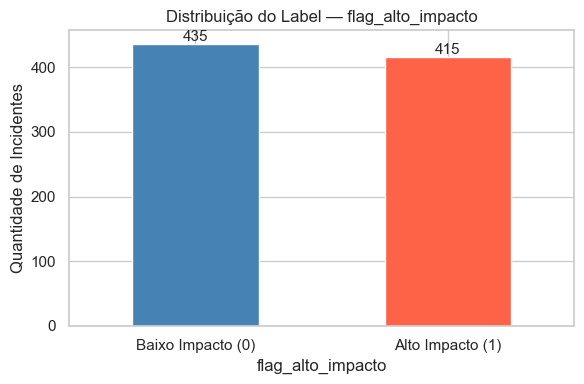

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
df_silver_inc['flag_alto_impacto'].value_counts().plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white'
)
ax.set_xticklabels(['Baixo Impacto (0)', 'Alto Impacto (1)'], rotation=0)
ax.set_title('Distribuição do Label — flag_alto_impacto')
ax.set_ylabel('Quantidade de Incidentes')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

In [47]:
# Join dos três datasets pela chave incident_id
df_silver = df_silver_inc.merge(
    df_silver_fin, on='incident_id', how='left', suffixes=('', '_fin')
).merge(
    df_silver_mkt, on='incident_id', how='left', suffixes=('', '_mkt')
)

print('Shape após merge:', df_silver.shape)
df_silver.head(3)

Shape após merge: (850, 73)


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,p_value_1d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,notes_mkt,created_at_mkt,flag_queda_acentuada,aumento_volatilidade
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,us,52,54,3940,True,QAA,2021-05-08 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,gb,51,nao_informado,250,False,nao_listada,2025-12-11 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,us,51,nao_informado,71369,True,BITW,2023-01-15 00:00:00+00:00,...,1.0,True,1.181988e+11,2.4652,0.027705,0.052161,nao_informado,2026-02-12 10:00:00+00:00,0.0,0.0245


In [48]:
Path('data/silver').mkdir(parents=True, exist_ok=True)
Path('data/silver/incidents_master').mkdir(parents=True, exist_ok=True)
Path('data/silver/financial_impact').mkdir(parents=True, exist_ok=True)
Path('data/silver/market_impact').mkdir(parents=True, exist_ok=True)

# Dataset consolidado
df_silver.to_parquet('data/silver/silver_master.parquet', index=False)

# Datasets individuais
df_silver_inc.to_parquet('data/silver/incidents_master/incidents_master.parquet', index=False)
df_silver_fin.to_parquet('data/silver/financial_impact/financial_impact.parquet', index=False)
df_silver_mkt.to_parquet('data/silver/market_impact/market_impact.parquet',       index=False)

print('Arquivos salvos:')
for path in sorted(Path('data/silver').rglob('*.parquet')):
    kb = path.stat().st_size / 1024
    print(f'  ✔ {path}  ({kb:.1f} KB)')

Arquivos salvos:
  ✔ data\silver\financial_impact\financial_impact.parquet  (42.6 KB)
  ✔ data\silver\incidents_master\incidents_master.parquet  (126.1 KB)
  ✔ data\silver\market_impact\market_impact.parquet  (70.3 KB)
  ✔ data\silver\silver_master.parquet  (233.5 KB)
  ✔ data\silver\silver_master_ml.parquet  (121.0 KB)


In [49]:
# Comparação
bronze_inc = Path('data/bronze/incidents_master/incidents_master.parquet').stat().st_size
bronze_fin = Path('data/bronze/financial_impact/financial_impact.parquet').stat().st_size
bronze_mkt = Path('data/bronze/market_impact/market_impact.parquet').stat().st_size

silver_inc = Path('data/silver/incidents_master/incidents_master.parquet').stat().st_size
silver_fin = Path('data/silver/financial_impact/financial_impact.parquet').stat().st_size
silver_mkt = Path('data/silver/market_impact/market_impact.parquet').stat().st_size

comp = pd.DataFrame([
    {'Dataset': 'incidents_master', 'Bronze (KB)': round(bronze_inc/1024,1), 'Prata (KB)': round(silver_inc/1024,1)},
    {'Dataset': 'financial_impact', 'Bronze (KB)': round(bronze_fin/1024,1), 'Prata (KB)': round(silver_fin/1024,1)},
    {'Dataset': 'market_impact',    'Bronze (KB)': round(bronze_mkt/1024,1), 'Prata (KB)': round(silver_mkt/1024,1)},
])
display(comp)

,Dataset,Bronze (KB),Prata (KB)
0,incidents_master,124.0,126.1
1,financial_impact,74.7,42.6
2,market_impact,91.4,70.3


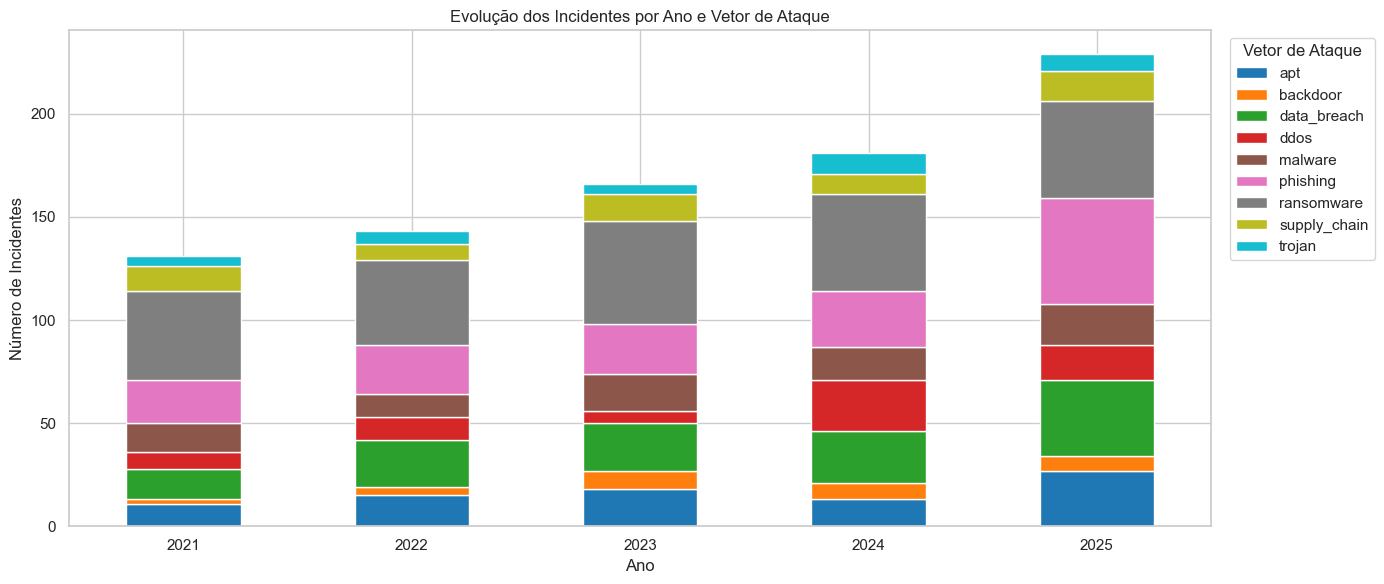

In [50]:
# Evolução dos incidentes por ano e vetor de ataque
pivot = (
    df_silver_inc
    .groupby(['ano_incidente', 'attack_vector_primary'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab10', edgecolor='white')
plt.title('Evolução dos Incidentes por Ano e Vetor de Ataque')
plt.xlabel('Ano')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=0)
plt.legend(title='Vetor de Ataque', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

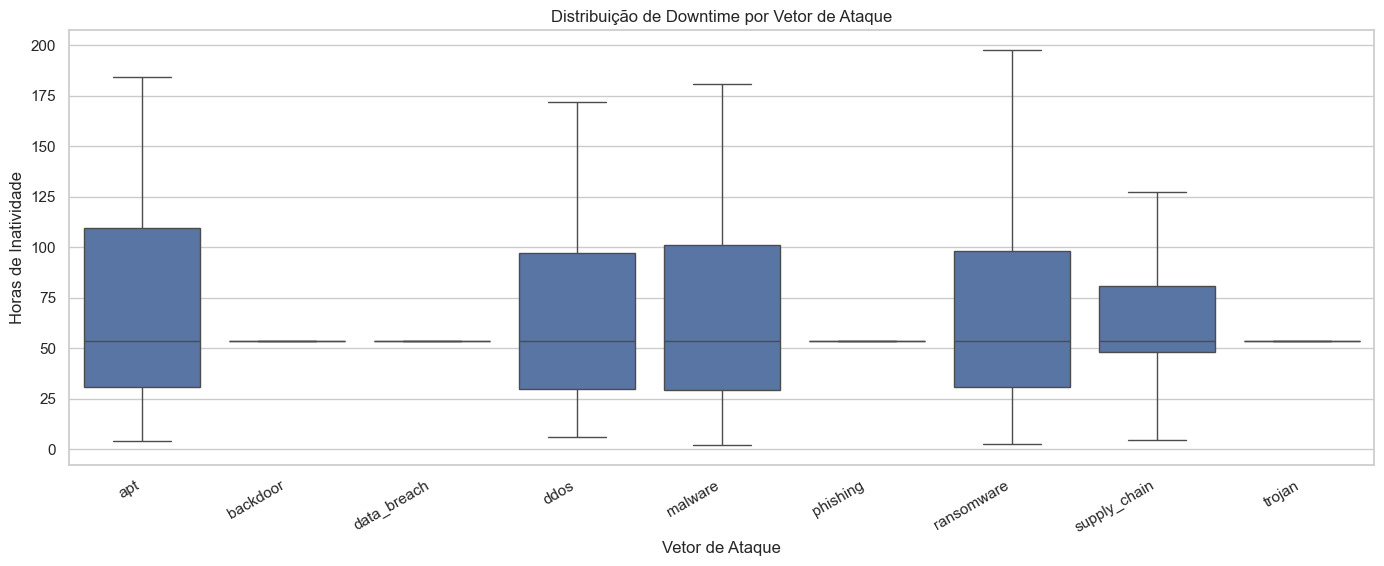

In [51]:
# Boxplot — downtime por vetor de ataque
ordem = (
    df_silver_inc.groupby('attack_vector_primary')['downtime_hours']
    .median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_silver_inc, x='attack_vector_primary', y='downtime_hours', 
            order=ordem, ax=ax, showfliers=False)
ax.set_title('Distribuição de Downtime por Vetor de Ataque')
ax.set_xlabel('Vetor de Ataque')
ax.set_ylabel('Horas de Inatividade')
plt.suptitle('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [52]:
# Sumário do pipeline
print('=' * 65)
print('  CAMADA PRATA — SUMÁRIO DAS TRANSFORMAÇÕES')
print('=' * 65)

print(f"""
DATASETS:
  incidents_master : {df_silver_inc.shape[0]:,} linhas × {df_silver_inc.shape[1]} colunas
  financial_impact : {df_silver_fin.shape[0]:,} linhas × {df_silver_fin.shape[1]} colunas
  market_impact    : {df_silver_mkt.shape[0]:,} linhas × {df_silver_mkt.shape[1]} colunas
  silver_master    : {df_silver.shape[0]:,} linhas × {df_silver.shape[1]} colunas

TRANSFORMAÇÕES APLICADAS:
  ✔ Leitura dos Parquets da Bronze
  ✔ Descarte de colunas de metadados da Bronze
  ✔ Tratamento de nulos (rotulação, imputação por mediana, zeros)
  ✔ Conversão de tipos (datas → datetime64[UTC])
  ✔ Padronização de categorias (lowercase, strip)
  ✔ Remoção de duplicatas por incident_id
  ✔ Criação de colunas derivadas (datas, flags, faixas)
  ✔ Remoção de colunas com data leakage ({len(leakage_inc + leakage_fin + leakage_mkt)} colunas)
  ✔ Criação do label de ML (flag_alto_impacto)
  ✔ Join dos três datasets pela chave incident_id
  ✔ Persistência em Parquet
""")

  CAMADA PRATA — SUMÁRIO DAS TRANSFORMAÇÕES

DATASETS:
  incidents_master : 850 linhas × 37 colunas
  financial_impact : 778 linhas × 13 colunas
  market_impact    : 358 linhas × 25 colunas
  silver_master    : 850 linhas × 73 colunas

TRANSFORMAÇÕES APLICADAS:
  ✔ Leitura dos Parquets da Bronze
  ✔ Descarte de colunas de metadados da Bronze
  ✔ Tratamento de nulos (rotulação, imputação por mediana, zeros)
  ✔ Conversão de tipos (datas → datetime64[UTC])
  ✔ Padronização de categorias (lowercase, strip)
  ✔ Remoção de duplicatas por incident_id
  ✔ Criação de colunas derivadas (datas, flags, faixas)
  ✔ Remoção de colunas com data leakage (21 colunas)
  ✔ Criação do label de ML (flag_alto_impacto)
  ✔ Join dos três datasets pela chave incident_id
  ✔ Persistência em Parquet



In [53]:
# Primeiras linhas do dataset final
df_silver.head(3)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,p_value_1d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,notes_mkt,created_at_mkt,flag_queda_acentuada,aumento_volatilidade
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,us,52,54,3940,True,QAA,2021-05-08 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,gb,51,nao_informado,250,False,nao_listada,2025-12-11 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,us,51,nao_informado,71369,True,BITW,2023-01-15 00:00:00+00:00,...,1.0,True,1.181988e+11,2.4652,0.027705,0.052161,nao_informado,2026-02-12 10:00:00+00:00,0.0,0.0245


In [54]:
# Tipos e nulos do dataset final
resumo_final = pd.DataFrame({
    'Dtype'  : df_silver.dtypes,
    'Nulos'  : df_silver.isna().sum(),
    '% Nulo' : (df_silver.isna().mean() * 100).round(1)
})
display(resumo_final)

,Dtype,Nulos,% Nulo
incident_id,object,0,0.0
company_name,object,0,0.0
company_revenue_usd,float64,0,0.0
country_hq,object,0,0.0
industry_primary,object,0,0.0
...,...,...,...
post_incident_volatility_30d,float64,492,57.9
notes_mkt,object,492,57.9
created_at_mkt,"datetime64[ns, UTC]",492,57.9
flag_queda_acentuada,float64,492,57.9
